In [1]:
with open("corpus.txt", "r", encoding="utf-8") as f:
    corpus = f.read()

In [2]:
# character tokenizer

chars = sorted(list(set(corpus)))
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

In [3]:
vocab_size = len(chars)
print(f"Vocabulary size: {vocab_size}")
print(f"Characters: {''.join(chars)}")

Vocabulary size: 201
Characters: 	
 !"#$%&'()*+,-./0123456789:;<=>?@ABCDEFGHIJKLMNOPQRSTUVWXYZ[]^_abcdefghijklmnopqrstuvwxyz{|}~£·ÀÁÄÆÇÈÉËÍÒÖÚàáâäæçèéêëíîïñòóôöùúûüÿĩŒœΑΕΠΣΤΦΧάέήίαβγδεζηθικλμνξοπρςστυφχωόύώἀἄἅἐἔἥὀὁὍὐὑὗὰὲὴὶὸῖῦῶ–—‘’“”•™


In [4]:
import torch
import torch.nn as nn

# the transformer block with a triangular causal mask, no flash attention

class TransformerBlockManual(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads,
                                          batch_first=True)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(),
            nn.Linear(d_ff, d_model))
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        normed = self.ln1(x)
        x = x + self.drop(
            self.attn(normed, normed, normed, attn_mask=mask)[0])
        x = x + self.drop(self.ff(self.ln2(x)))
        return x

In [5]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.n_heads = n_heads
        self.d_head = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(),
            nn.Linear(d_ff, d_model))
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape

        normed = self.ln1(x)

        q = self.W_q(normed)
        k = self.W_k(normed)
        v = self.W_v(normed)

        q = q.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.d_head).transpose(1, 2)

        attn = torch.nn.functional.scaled_dot_product_attention(
            q, k, v, dropout_p=self.drop.p, is_causal=True)

        attn = attn.transpose(1, 2).contiguous().view(B, T, C)
        attn = self.W_o(attn)

        x = x + self.drop(attn)
        x = x + self.drop(self.ff(self.ln2(x)))
        return x

In [6]:
def make_causal_mask(seq_len, device):
    # matrix where future positions are masked out
    mask = torch.triu(torch.ones(seq_len, seq_len, device=device), diagonal=1)
    mask = mask.masked_fill(mask == 1, float('-inf'))
    return mask

In [7]:
class GPT(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff, context_len, dropout=0.1, use_flash=True):
        super().__init__()
        self.use_flash = use_flash
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(context_len, d_model)
        self.drop = nn.Dropout(dropout)

        block_class = TransformerBlock if use_flash else TransformerBlockManual
        self.blocks = nn.ModuleList([
            block_class(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.ln_final = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        seq_len = x.shape[1]
        positions = torch.arange(seq_len, device=x.device)
        x = self.drop(self.token_emb(x) + self.pos_emb(positions))

        if self.use_flash:
            for block in self.blocks:
                x = block(x)
        else:
            mask = make_causal_mask(seq_len, x.device)
            for block in self.blocks:
                x = block(x, mask=mask)

        x = self.ln_final(x)
        return self.head(x)

In [8]:
context_len = 256

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = GPT(vocab_size, 256, 8, 6, 1024, 256).to(device)  # with flash attention

In [10]:
# encode the entire corpus
data = torch.tensor([char_to_idx[c] for c in corpus], dtype=torch.long)

# train/validation split (90/10)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print(f"Train tokens: {len(train_data)}")
print(f"Val tokens: {len(val_data)}")

Train tokens: 4882914
Val tokens: 542546


In [11]:
def get_batch(data, batch_size, context_len, device):
    ix = torch.randint(len(data) - context_len, (batch_size,))
    x = torch.stack([data[i:i+context_len] for i in ix])
    y = torch.stack([data[i+1:i+context_len+1] for i in ix])
    return x.to(device), y.to(device)

In [12]:
from google.colab import files

def generate(model, prompt, max_new_chars, device, temperature=1.0):
    model.eval()

    x = torch.tensor([char_to_idx[c] for c in prompt], dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        for _ in range(max_new_chars):

            x_crop = x[:, -context_len:]
            logits = model(x_crop)

            logits = logits[:, -1, :] / temperature
            probs = torch.nn.functional.softmax(logits, dim=-1)
            next_char = torch.multinomial(probs, num_samples=1)
            x = torch.cat([x, next_char], dim=1)

    return ''.join([idx_to_char[i.item()] for i in x[0]])

In [13]:
from tqdm.notebook import tqdm
from google.colab import files

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer,
    lambda step: min(1.0, (step + 1) / 1000))

loss_fn = nn.CrossEntropyLoss()
n_steps = 30_000

train_losses = []
val_losses = []

for step in tqdm(range(1, n_steps + 1)):
    model.train()
    x_train, y_train = get_batch(train_data, 64, 256, device)

    logits = model(x_train)
    loss = loss_fn(logits.view(-1, vocab_size), y_train.view(-1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()

    if step % 250 == 0:
        model.eval()
        train_loss_avg = 0
        val_loss = 0
        with torch.no_grad():
            for _ in range(5):
                x_train_eval, y_train_eval = get_batch(train_data, 64, 256, device)
                train_logits = model(x_train_eval)
                train_loss_avg += loss_fn(
                    train_logits.view(-1, vocab_size),
                    y_train_eval.view(-1)
                ).item()

                x_val, y_val = get_batch(val_data, 64, 256, device)
                val_logits = model(x_val)
                val_loss += loss_fn(
                    val_logits.view(-1, vocab_size),
                    y_val.view(-1)
                ).item()

        train_loss_avg /= 5
        val_loss /= 5
        val_bpc = val_loss / 0.6931

        tqdm.write(f"step {step} | train loss {train_loss_avg:.4f} | val loss {val_loss:.4f} | val bpc {val_bpc:.4f}")
        train_losses.append(train_loss_avg)
        val_losses.append(val_loss)

    if step % 2000 == 0:
        sample = generate(model, prompt="<book>\n", max_new_chars=300, device=device)
        tqdm.write(f"\n{sample}\n")
        torch.save(model.state_dict(), "model_extended_dataset.pt")
        files.download('model_extended_dataset.pt')

  0%|          | 0/30000 [00:00<?, ?it/s]

step 250 | train loss 2.7192 | val loss 2.6833 | val bpc 3.8715
step 500 | train loss 2.5100 | val loss 2.4870 | val bpc 3.5883
step 750 | train loss 2.3053 | val loss 2.3055 | val bpc 3.3263
step 1000 | train loss 2.1264 | val loss 2.1467 | val bpc 3.0973
step 1250 | train loss 2.0241 | val loss 2.0223 | val bpc 2.9177
step 1500 | train loss 1.9360 | val loss 1.9211 | val bpc 2.7718
step 1750 | train loss 1.8883 | val loss 1.9010 | val bpc 2.7427
step 2000 | train loss 1.8252 | val loss 1.8190 | val bpc 2.6244

<book>
  Would alfor wat a cagintely wers
  An' I’s Hogho forn, tink fistls vare
  Induck the bod ma sugh it an from,
     This sulll her shord knows their as slenone
   It he swail hem desp well, bout flev.d .


  "Whalch slain hey laves, lown that to who;
    Who kead aweass horgimes
    "Rohckling their



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

step 2250 | train loss 1.7704 | val loss 1.7852 | val bpc 2.5757
step 2500 | train loss 1.7272 | val loss 1.7536 | val bpc 2.5300
step 2750 | train loss 1.7256 | val loss 1.7006 | val bpc 2.4536
step 3000 | train loss 1.6842 | val loss 1.6489 | val bpc 2.3790
step 3250 | train loss 1.6349 | val loss 1.6321 | val bpc 2.3548
step 3500 | train loss 1.6192 | val loss 1.6088 | val bpc 2.3211
step 3750 | train loss 1.6112 | val loss 1.5834 | val bpc 2.2845
step 4000 | train loss 1.5805 | val loss 1.5898 | val bpc 2.2937

<book>
    “That dray      and goests he’s aed,
     “With helde see thou keep down at ressed she woman when
  For look, impow snows
     (_Maunt like a' noor shame and my than nobs ;
  She hus soa-heard over nor sorvers snothful he,
     As the clouds rowd the repons of fells.

    |My Gildene Ravoh|:
   



...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

step 28250 | train loss 1.1211 | val loss 1.1996 | val bpc 1.7308
step 28500 | train loss 1.1009 | val loss 1.2165 | val bpc 1.7551
step 28750 | train loss 1.1318 | val loss 1.1994 | val bpc 1.7305
step 29000 | train loss 1.0964 | val loss 1.2089 | val bpc 1.7442
step 29250 | train loss 1.0899 | val loss 1.1915 | val bpc 1.7191
step 29500 | train loss 1.1117 | val loss 1.2104 | val bpc 1.7463
step 29750 | train loss 1.0890 | val loss 1.2157 | val bpc 1.7540
step 30000 | train loss 1.0710 | val loss 1.2031 | val bpc 1.7358

<book>

<book>
 THE PROJECT, XGI., 1725.  Denâ.

   PROHIMER was all mighty good, who make him not be attached
   That he tears is,--opopographic light into bed.
   This maiden householding (which host was pigeon concealed for,
   Is,--if you astonished ;--but he didn't denote the world it,
   I never fres



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

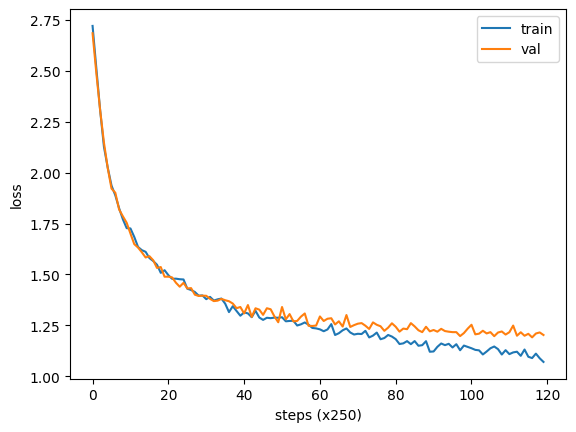

In [14]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.legend()
plt.xlabel('steps (x250)')
plt.ylabel('loss')
plt.show()